#Leer archivos



In [ ]:
import pandas as pd
ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/PUNTOS/Base de datos/Finales/Compilado.xlsx"

puntos = pd.read_excel(ruta, decimal=",")
puntos.info()
puntos.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ID        2341 non-null   int64         
 1   Tipo      2341 non-null   object        
 2   Fecha     2341 non-null   datetime64[ns]
 3   Latitud   2341 non-null   float64       
 4   Longitud  2341 non-null   float64       
 5   Sitio     2273 non-null   object        
 6   Fuente    2341 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 128.2+ KB


,ID,Tipo,Fecha,Latitud,Longitud,Sitio,Fuente
0,1,Flujo,1921-01-04,6.194158,-75.570134,*,SIMMA
1,2,Flujo,1921-03-03,6.196886,-75.565530,*,SIMMA
2,3,Flujo,1921-03-13,6.206115,-75.565556,*,SIMMA
3,4,Deslizamiento,1921-10-22,6.250551,-75.595250,*,SIMMA
4,5,Flujo,1923-06-16,6.230405,-75.614995,DE MOLINA,SIMMA


#Dispersión

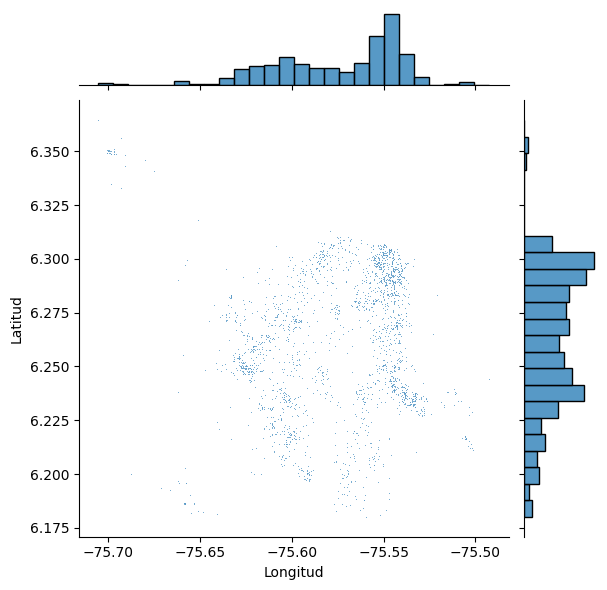

In [ ]:
import seaborn as sbn
sbn.jointplot(x='Longitud', y='Latitud', data=puntos, s=0.5);

#Áreas

<Axes: >

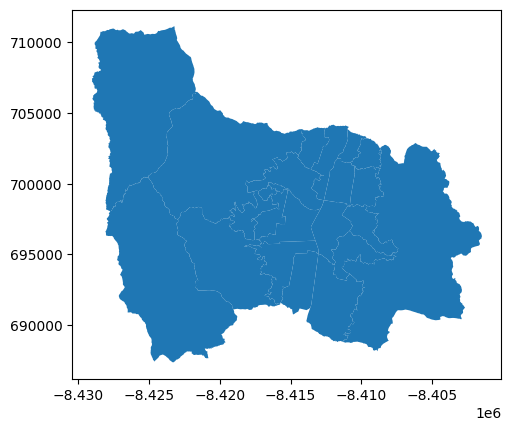

In [ ]:
import geopandas as gpd
comuna = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/comunas_med");
comuna.head()
comuna.plot()

In [ ]:
menm = gpd.GeoDataFrame(puntos,
    geometry=gpd.points_from_xy(puntos.Longitud, puntos.Latitud),
    crs="EPSG:4326")

In [ ]:
comuna = comuna.to_crs("EPSG:9377")
menm = menm.to_crs("EPSG:9377")

In [ ]:
comuna.crs
menm.crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

#Puntos x área

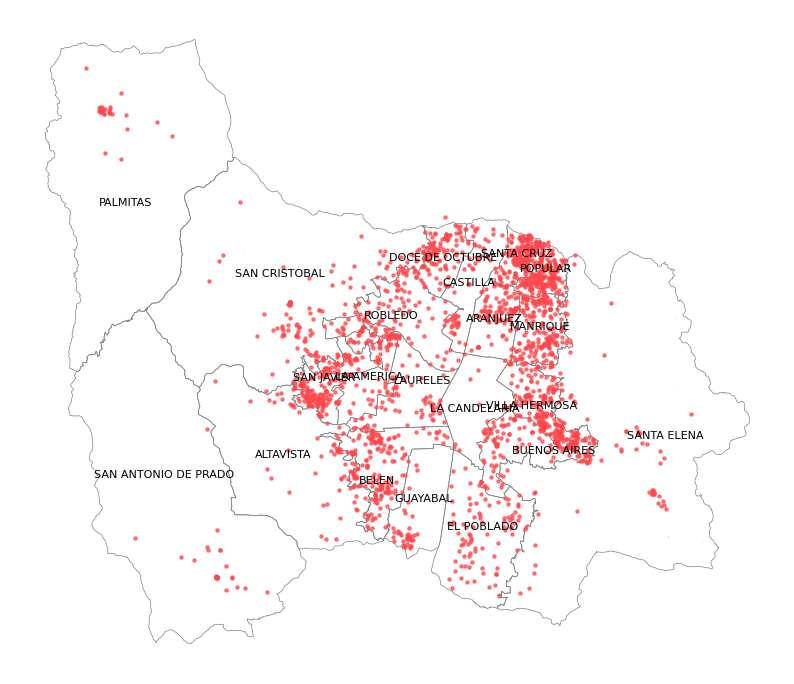

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))

# Áreas
comuna.plot(ax=ax, facecolor="none", edgecolor="gray",linewidth=0.5)

# puntos
menm.plot(ax=ax, color="xkcd:light red", markersize=5,alpha=0.7)

comuna["coords"] = comuna.geometry.representative_point()

for idx, row in comuna.iterrows():
    ax.text(
        row["coords"].x,
        row["coords"].y,
        row["NOMBRE"],
        fontsize=8,
        ha='center')

ax.set_axis_off()
plt.show()

In [ ]:
!pip install contextily
import contextily as ctx

#Mapa de calor de los movimientos en masa

##Ancho de banda 0.25

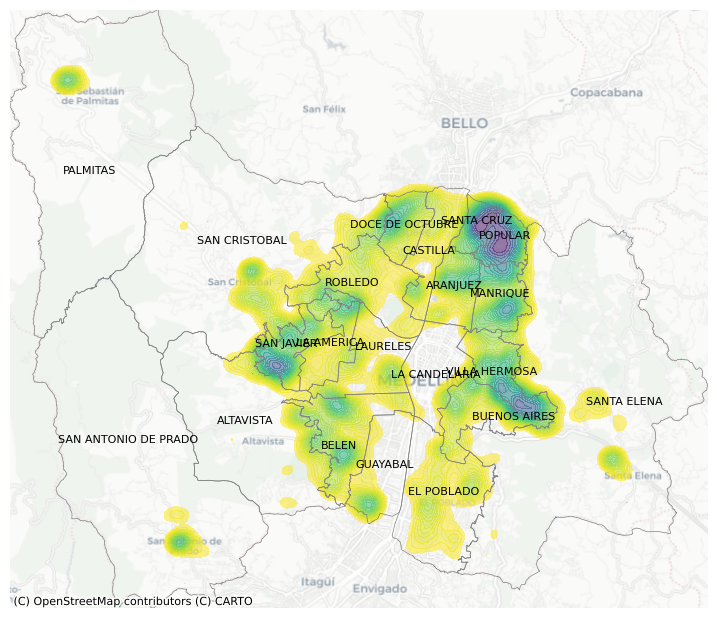

In [ ]:
f, ax = plt.subplots(1, figsize=(9, 9))
x = menm.geometry.x
y = menm.geometry.y
sbn.kdeplot(x=x, y=y, n_levels=30,fill=True,alpha=0.55,cmap='viridis_r',
    bw_adjust=0.25)

comuna.plot(ax=ax, facecolor="none", edgecolor="gray",linewidth=0.5)
comuna["coords"] = comuna.geometry.representative_point()

for idx, row in comuna.iterrows():
    ax.text(
        row["coords"].x,
        row["coords"].y,
        row["NOMBRE"],
        fontsize=8,
        ha='center')

ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron, crs="EPSG:9377")
ax.set_axis_off();
minx, miny, maxx, maxy = comuna.total_bounds

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
plt.show()

##Ancho de banda 0.5

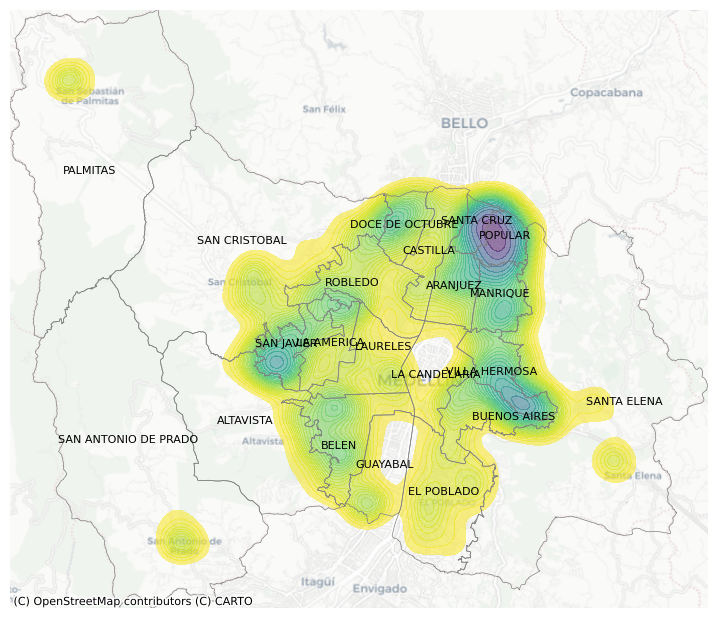

In [ ]:
f, ax = plt.subplots(1, figsize=(9, 9))
x = menm.geometry.x
y = menm.geometry.y
sbn.kdeplot(x=x, y=y, n_levels=30,fill=True,alpha=0.55,cmap='viridis_r',
    bw_adjust=0.5)

comuna.plot(ax=ax, facecolor="none", edgecolor="gray",linewidth=0.5)
comuna["coords"] = comuna.geometry.representative_point()

for idx, row in comuna.iterrows():
    ax.text(
        row["coords"].x,
        row["coords"].y,
        row["NOMBRE"],
        fontsize=8,
        ha='center')

ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron, crs="EPSG:9377")
ax.set_axis_off();
minx, miny, maxx, maxy = comuna.total_bounds

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
plt.show()

##Ancho de banda 1

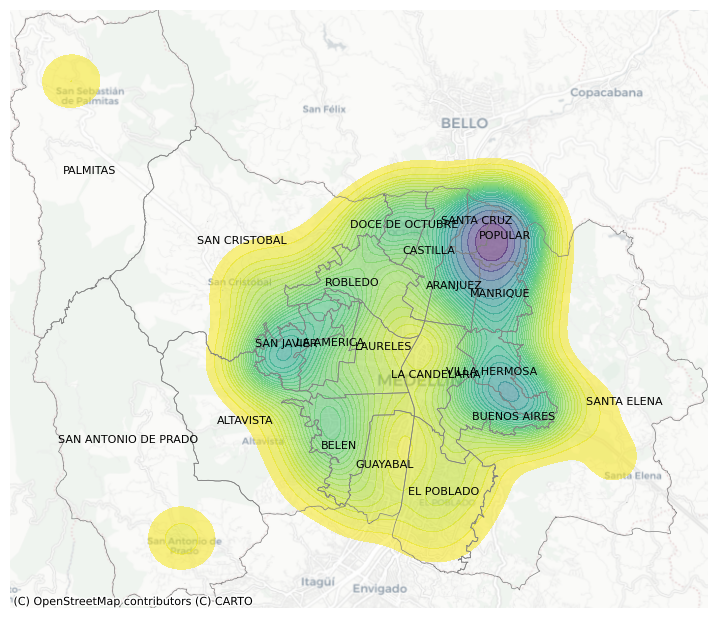

In [ ]:
f, ax = plt.subplots(1, figsize=(9, 9))
x = menm.geometry.x
y = menm.geometry.y
sbn.kdeplot(x=x, y=y, n_levels=30,fill=True,alpha=0.55,cmap='viridis_r',
    bw_adjust=1)

comuna.plot(ax=ax, facecolor="none", edgecolor="gray",linewidth=0.5)
comuna["coords"] = comuna.geometry.representative_point()

for idx, row in comuna.iterrows():
    ax.text(
        row["coords"].x,
        row["coords"].y,
        row["NOMBRE"],
        fontsize=8,
        ha='center')

ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron, crs="EPSG:9377")
ax.set_axis_off();
minx, miny, maxx, maxy = comuna.total_bounds

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
plt.show()